# NB1 : Building Schema & Preliminary Feature Engineering


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import os

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of highly-cited scientific journals using co-author metrics alone. 

## Notebook Introduction

In this notebook, we perform preliminary data cleaning on the raw data sets pulled from Google Scholar using the [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scraping software and publication metric hosting online data base [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php). 

Our goal is to create a relational database of data tables that contain minimal null entries, duplicated rows and uniform formatting of features. To start, the database will include three tables:

1. `profile_df`: The meta data for each of the sampled Google Scholar profiles.
 
2. `papers_df`: All the citation entries for each of the first 1000 papers pulled from the sampled Google Scholar profiles.

3. `jour_df`: Contains metrics about publications sources divided into different subject areas. 

# Section 1: Data Cleaning & Building Relational Data Tables

## 1.1 Creating Keys To Join `profile_df` and `papers_df`

The goal of **Section 1.1** is to join each citation entry in `papers_df` with its corresponding profile author in `profile_df`. We perform this join by assigning foreign keys to entries in `papers_df` and primary keys to `profile_df`. Currently, the entries in `papers_df` do not have any columns that indicate which Google Scholar profile they were scrapped from. Therefore, to assign the foreign keys to `papers_df`, we demonstrate a method that identifies patterns in the `Cites` features that correspond to changes in the profile author assignment. 

### 1.1.1 Inspecting the Data Sets

First, let's inspect `profile_df`

In [82]:
profile_df = pd.read_csv(r"RawData\PublishOrPerish\author_PoPMetrics_V2.2.csv")

In [83]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Query              616 non-null    object 
 1   Source             616 non-null    object 
 2   Papers             616 non-null    int64  
 3   Citations          616 non-null    int64  
 4   Years              616 non-null    int64  
 5   Cites_Year         616 non-null    float64
 6   Cites_Paper        616 non-null    float64
 7   Cites_Author       616 non-null    float64
 8   Papers_Author      616 non-null    float64
 9   Authors_Paper      616 non-null    float64
 10  h_index            616 non-null    int64  
 11  g_index            616 non-null    int64  
 12  hc_index           616 non-null    int64  
 13  hI_index           616 non-null    float64
 14  hI_norm            616 non-null    int64  
 15  AWCR               616 non-null    float64
 16  AW_index           616 non

`profile_df` has 616 entries and 34 columns with no null values. 
Let's investigate `papers_df`

In [84]:
papers_df = pd.read_csv(r"RawData\PublishOrPerish\results_PoPCites_V2.2.csv",low_memory = True)

In [85]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33531 entries, 0 to 33530
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           33531 non-null  int64  
 1   Authors         33511 non-null  object 
 2   Title           33531 non-null  object 
 3   Year            32272 non-null  float64
 4   Source          31433 non-null  object 
 5   Publisher       218 non-null    object 
 6   ArticleURL      0 non-null      float64
 7   CitesURL        33531 non-null  object 
 8   GSRank          33531 non-null  int64  
 9   QueryDate       33531 non-null  object 
 10  Type            29640 non-null  object 
 11  DOI             0 non-null      float64
 12  ISSN            0 non-null      float64
 13  CitationURL     33531 non-null  object 
 14  Volume          25912 non-null  float64
 15  Issue           19123 non-null  float64
 16  StartPage       25035 non-null  float64
 17  EndPage         24814 non-null 

`papers_df` has 33,531 entries and 26 columns. 

In reguards to `profile_df`, we are only interested in the column `Query` that holds the name and institutions of the researcher. While the other columns in `profile_df` could give us exciting metrics about the researcher for our model to train on, because it is unlikely that most of the cited authors in the over 30,000 citation entries in `paper_df` would be accounted for in the 616 entires in `profile_df`, including the additional metrics from `profile_df` would lead to an imbalance of features for each author. Therefore, let’s modify `profile_df` only to contain the `Query` column.

*Note on duplicated entries in `profile_df`*

Because the web scrapping software appended the entries in `papers_df` and `profile_id` in the same order, if the software scrapped any profiles more than once, their entries would be appended to `papers_df` more than once. However, identifying which entries in `papers_df` were duplicated because the software scrapped their corresponding Google Scholar profile more than once from entries duplicated for other reasons will first require assigning the foreign key to the entries in `papers_df`. Below, we demonstrate how to use this appending order in `papers_df` and `profile_df` to assign foreign keys to the entries in `papers_df`. Therefore, while `profile_df` may contain duplicate entries, removing these entries before assigning foreign keys to `papers_df` will prevent all the entries in `papers_df` from being properly assigned foreign keys.

In [86]:
profile_df = profile_df.loc[:, 'Query']

In [87]:
profile_df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 616 entries, 0 to 615
Series name: Query
Non-Null Count  Dtype 
--------------  ----- 
616 non-null    object
dtypes: object(1)
memory usage: 4.9+ KB


### 1.1.2 Create Primary Keys in `profile_df`

The first step to being able to join `papers_df` with `profile_df` is to assign a primary key to each of the entries in `profile_df`. We can do this by assigning the indexing column as the primary key `id`. 

In [88]:
# Resetting the index to insert the index into dataframe columns.
profile_df = profile_df.reset_index()

# Renaming the columns
profile_df.columns = ['id', 'Query']

In [89]:
# Setting data type of `id` to int16
profile_df['id'] = profile_df['id'].astype('int16')

profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      616 non-null    int16 
 1   Query   616 non-null    object
dtypes: int16(1), object(1)
memory usage: 6.1+ KB


### 1.1.3 Creating Foreign Keys in `papers_df`

We will create a new column in `papers_id` called `profile_id` which will hold a foreign key to link the entries in the `papers_df` with their respective Google scholar profiles in `profile_df`. This will be used to join `papers_df` and `profile_df`. Since the web scraper exported the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `profile_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `profile_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | profile_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [90]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

# findings starting and endings points for each profile_id entry
for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = profile_df.shape

# Assign profile_ids
profile_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    profile_id[start:stop] = i

# Save profile series to df
quer_ser = pd.Series(profile_id)
papers_df['profile_id'] = quer_ser

We see that the `papers_df` has a new column `profile_id`

In [91]:
papers_df['profile_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: profile_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


We can check if all the entires in the `profile_df` are accounted for in the `profile_id` column by checking if the unique values in the `profile_id` column equals the number of entries in the `profile_df`.

In [92]:
papers_df['profile_id'].value_counts().count() == profile_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `profile_id` column was successful! Let's confirm further that all the entries in `paper_df` are able to join to a entry in `profile_id` by performing a left join on `profile_id`.

In [93]:
join_df = pd.merge(left = papers_df, right = profile_df, left_on = 'profile_id', right_on = 'id', how = 'left')

# Counting the null values in the `id` column to determine how many entries in `papers_df` were not able to join 
num = join_df['id'].isna().sum()
print(f'{num} entries in papers_df did NOT have a corresponding id in profile_df')

0 entries in papers_df did NOT have a corresponding id in profile_df


All the entries in `papers_df` were able to join to an entry in `profile_id`! We now have a foreign key to join the entires in `papers_df` to `profile_df`. This will be helpful when needing to access information only available in the from the `profile_df` for each entry.

---

## 1.2 Cleaning `papers_df`

The objective of **Section 1.2** is to reduce the occurrence of null values and duplicated entries in papers_df to simplify the process of future feature engineering and model implementation. Because our ultimate aim is to classify entries into various tiers of highly-cited scientific journals solely based on co-author metrics, while removing null values and duplicated entries, we will prioritize retaining features in `papers_df` that have the potential to describe the author's publication prestige or the publication prestige of the citation entry itself.

First, let's investigate if there any duplicated entries in `papers_df`.

In [94]:
papers_df.duplicated().sum()

0

There are no duplicate entries in `papers_df`. Let's move on to investigating the null values.

Let's access the percentage of null values in `papers_df`for each column

In [95]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

RelatedURL        100.000000
ArticleURL        100.000000
FullTextURL       100.000000
Abstract          100.000000
DOI               100.000000
ISSN              100.000000
Publisher          99.349855
Issue              42.969193
EndPage            25.996839
StartPage          25.337747
Volume             22.722257
Type               11.604187
Source              6.256897
Age                 3.754734
Year                3.754734
Authors             0.059646
Cites               0.000000
CitesPerAuthor      0.000000
AuthorCount         0.000000
CitationURL         0.000000
CitesPerYear        0.000000
ECC                 0.000000
QueryDate           0.000000
GSRank              0.000000
CitesURL            0.000000
Title               0.000000
profile_id          0.000000
dtype: float64

Since the entries in the features where over 99% of the entries are null values are so sparse, let’s drop those columns entirely. 

In [96]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher'], axis = 1)

In [97]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Issue             42.969193
EndPage           25.996839
StartPage         25.337747
Volume            22.722257
Type              11.604187
Source             6.256897
Age                3.754734
Year               3.754734
Authors            0.059646
AuthorCount        0.000000
CitesPerAuthor     0.000000
CitesPerYear       0.000000
ECC                0.000000
Cites              0.000000
CitationURL        0.000000
QueryDate          0.000000
GSRank             0.000000
CitesURL           0.000000
Title              0.000000
profile_id         0.000000
dtype: float64

Since publications are typically added to journals in the order of acceptance, the `Volume`, `StartPage`, `EndPage` and `Issue` of each entry are unlikely to offer any valuable information about the publication's prestige. Furthermore, these columns have null values in over 20% of their entries. As a result, we should remove these columns from the dataset. Additionally, since `Age` and `Year` both contain information about when the citation was published (as evident by the identical percentage of null values in each feature) we can drop one of them. Let's drop `Age` and keep `Year`.

In [98]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

Let's look at the remaining null values.

In [99]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Type              11.604187
Source             6.256897
Year               3.754734
Authors            0.059646
Cites              0.000000
Title              0.000000
CitesURL           0.000000
GSRank             0.000000
QueryDate          0.000000
CitationURL        0.000000
ECC                0.000000
CitesPerYear       0.000000
CitesPerAuthor     0.000000
AuthorCount        0.000000
profile_id         0.000000
dtype: float64

Let's investigate the null values for the `Type` column. Let's start by looking at the value counts for each of the `Type` categories.

Text(0.5, 1.0, 'Distribution of Entry Types')

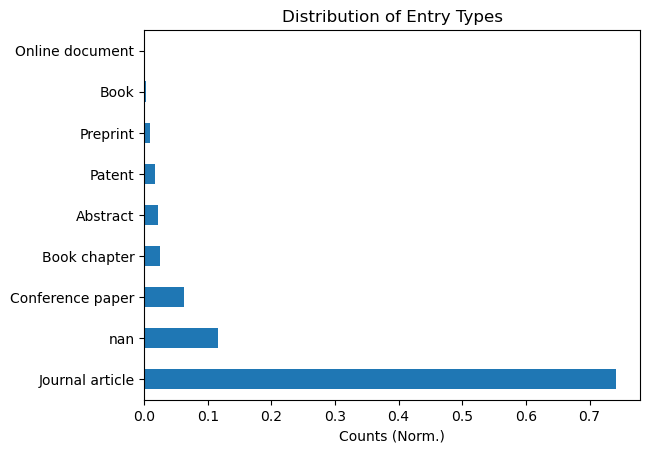

In [100]:
papers_df['Type'].value_counts(normalize = True, dropna = False).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

Based on the distribution of the `Type` column, it appears that null values account for slightly over 10% of the entries, while over 70% of the entries are classified as `Journal Article`. One method of removing the null entries in the `Type` column is to isolate the data set to only have the entries categorized as `Journal Article`. By focusing solely on the entries in the `Journal Article` class, we not only eliminate any existing null values but also potentially address any class imbalances within the remaining categories. This approach may improve the accuracy of the model at classifying citations into their publication tier, as it specifically trains the model to recognize features that are most predictive to classify citations of journals and not other publication types.

In [101]:
idx = papers_df[papers_df['Type'] != 'Journal article'].index
papers_df = papers_df.drop(idx).reset_index(drop = 'True')

Let's look at the remaining null values.

In [102]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Year              0.048214
Authors           0.036161
Source            0.004018
Cites             0.000000
Title             0.000000
CitesURL          0.000000
GSRank            0.000000
QueryDate         0.000000
Type              0.000000
CitationURL       0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
profile_id        0.000000
dtype: float64

Since the remaining null entries *combined* represent < 0.1% of the total entries in `papers_df`. Let's drop the entries containing any null values.

In [103]:
rows_before, cols_before = papers_df.shape

In [104]:
papers_df = papers_df.dropna().reset_index(drop = True)

In [105]:
rows_after, cols_after = papers_df.shape

In [106]:
per_before = rows_after/rows_before
print('After dropping the entries containing any null values, papers_df still maintains {:0.3%} of its original entries'.format(per_before))
print(f"That's {rows_after} entries")

After dropping the entries containing any null values, papers_df still maintains 99.912% of its original entries
That's 24867 entries


We still have over 20,000 entries which is a healthy amount.

Let's look at the distribution of remaining null values.

In [107]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
CitesURL          0.0
GSRank            0.0
QueryDate         0.0
Type              0.0
CitationURL       0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
profile_id        0.0
dtype: float64

Let's check the null value distribution.

In [108]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
CitesURL          0.0
GSRank            0.0
QueryDate         0.0
Type              0.0
CitationURL       0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
profile_id        0.0
dtype: float64

Hurray! There are zero remaining null values for `papers_df`. To conclude, we successfully removed all the null values in the `papers_df` to create a data frame of citation entries. We found the most effective method of removing null values was to isolate the data set only to include entries with `Types` values `Journal article` and removing columns that had over 99% of the entries as null and removing columns that described indexing information for the citation such as `Volume`, `StartPage`, `EndPage` and `Issue`. 

---

## 1.3 Building `jour_df` 

The goal of **Section 1.3** is to concatenate the individual data set pulled from [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php) into a single data frame called `jour_df`.

Given the scope of researchers who have published work in perovskites, we have pulled publications from the following subject areas:
- Materials Science
- Environmental Science
- Engineering
- Energy
- Chemistry
- Physics and Astronomy
- Chemical Engineering
- Multidisciplinary (contains journals of interest such as Nature and Science)

To ensure the successful conversion of the original data from the CSV file into a Pandas data frame, we must first perform preliminary text format editing. We accomplish this by iterating through the lines in the CSV file and using the `.replace()` method to modify any strings that require reformatting. We then append each line, whether edited or not, to a `txt` file that will be utilized in generating the Pandas data frame. Our specific modification involves replacing instances of `&amp;` with `&amp;`, as the delimiter is `;` and we want to avoid the columns splitting the string after `&amp;`.

*Note*: Attempts were made to edit the CSV files directly, but this ended up being the most effective method.

In [109]:
folder_path = r'RawData\SciMago'
folder_out = r'RawData\SciMago\output'
folder = os.listdir(folder_path)[1:] # excludes the output directory

print('Here are the CSV Files being Edited:')
for file in folder:
    path = os.path.join(folder_path, file)
    print(file)
    out_path = os.path.join(folder_out, file).replace('.csv', '')
    with open(path, 'r') as f:
        with open(out_path + '_out.txt', 'a') as g:
            for idx, line in enumerate(f):
                    # need to replace '&amp' with &
                    new_line = line.replace('&amp;', '&')
                    g.write(new_line)

Here are the CSV Files being Edited:
scimagojr 2021  Subject Area - Chemical Engineering.csv
scimagojr 2021  Subject Area - Chemistry.csv
scimagojr 2021  Subject Area - Energy.csv
scimagojr 2021  Subject Area - Engineering.csv
scimagojr 2021  Subject Area - Environmental Science.csv
scimagojr 2021  Subject Area - Materials Science.csv
scimagojr 2021  Subject Area - Multidisciplinary.csv
scimagojr 2021  Subject Area - Physics and Astronomy.csv


Next, we will concatenate the individual data frames stored in the `txt` files into one data frame titled `jour_df`.

In [110]:
folder = os.listdir(folder_out)

jour_df = pd.DataFrame()

print('Here are the TXT Files being Edited:')
for file in folder:
    path = os.path.join(folder_out, file)
    print(file)
    temp_file = np.genfromtxt(path, delimiter=';', usecols = (2,3,5,7,15,16), dtype = '<U500')
    temp_df = pd.DataFrame(temp_file[1:], columns = temp_file[0,:])
    jour_df = pd.concat([jour_df, temp_df], axis = 0)

Here are the TXT Files being Edited:
scimagojr 2021  Subject Area - Chemical Engineering_out.txt
scimagojr 2021  Subject Area - Chemistry_out.txt
scimagojr 2021  Subject Area - Energy_out.txt
scimagojr 2021  Subject Area - Engineering_out.txt
scimagojr 2021  Subject Area - Environmental Science_out.txt
scimagojr 2021  Subject Area - Materials Science_out.txt
scimagojr 2021  Subject Area - Multidisciplinary_out.txt
scimagojr 2021  Subject Area - Physics and Astronomy_out.txt


Here is the resulting data frame `jour_df`

In [111]:
jour_df.head(4)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,"20,120",463,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,"12,887",84,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,"11,811",67,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe


In [112]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 114916 rows and 6 columns


Here are the descriptions of the columns that make up `jour_df` (pulled from https://www.scimagojr.com/journalrank.php)

- `Title`: The title of the publication 
- `Type`: The type of publication (journal article, book, etc.)
- `SJR`: "SCImago Journal Rank indicator. It is a measure of journal's impact, influence or prestige. It expresses the average number of years weighted citations received in the selected year by the documents published in the journal in the three previous years.
- `H index`: "Journal's number of citations (h) that have received at least h citations over the whole period"
- `Country`: The location of the publisher
- `Region`: The region of the publisher's country.

To summerize, in this section we imported a data set of publications and their metrics as the data frame `jour_df` to be able to add additional features to `paper_df` that would describe an entry's rank.

---

## 1. 4 Cleaning `jour_df`

The goal of **Section 1.4** is to reduce the occurrence of null values and duplicated entries. 


Additionally in such that we can *join* the titles of the publications onto the publication titles in the `papers_df`.

First, let's check to see if `jour_df` has any duplicate entries. We'd expect there to be duplicate publication entires if a publication is present in more than one subject area's data frame. (Example: the publication `ACS Nano` could be considered to span both the Materials Science and Chemistry subject area, so it would be added to `jour_df` from both subject area data frames).

In [113]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 108394 duplicated entires


Let's remove the duplicated entries.

In [114]:
jour_df = jour_df.drop_duplicates(ignore_index = True)

In [115]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 0 duplicated entires


In [116]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 6522 rows and 6 columns


It looks like most of the entires in `jour_df` were duplicated since the the data frame originally had over 57,000 entries and now has about 6,5000.

Let's look at some formatting changes we can make to the entires.

In [117]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,"20,120",463,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,"12,887",84,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,"11,811",67,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe
4,"""Nature Chemistry""",journal,"8,384",249,United Kingdom,Western Europe


In [118]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    6522 non-null   object
 1   Type     6522 non-null   object
 2   SJR      6522 non-null   object
 3   H index  6522 non-null   object
 4   Country  6522 non-null   object
 5   Region   6522 non-null   object
dtypes: object(6)
memory usage: 305.8+ KB


`Title`, `Type` `Country` and `Region` appear to be assigned the appropriate data type (object) while `SJR` and `H index` should be changed to a numeric data type. First, let's  replace `,` with `.` in `SJR` so it can be interpreted as a `float` and then convert `SJR` and `H index` into numeric data types.

In [119]:
jour_df = jour_df.assign(SJR = jour_df.apply(lambda x: x['SJR'].replace(',', '.'), axis = 1))

In [120]:
for idx in jour_df['H index'].index:
    try: 
        # try to convert str to integer
        jour_df.loc[idx, 'H index'] = int(jour_df.loc[idx, 'H index'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'H index'] = np.nan 
    
# Convert to float data type (using float insted of int because I can't conver NAN to int)
jour_df['H index'] = jour_df['H index'].astype('float16')

for idx in jour_df['SJR'].index:
    try: 
        # try to convert string to float
        jour_df.loc[idx, 'SJR'] = float(jour_df.loc[idx, 'SJR'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'SJR'] = np.nan

# Convert to float data type
jour_df['SJR'] = jour_df['SJR'].astype('float64')

In [121]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6522 non-null   object 
 1   Type     6522 non-null   object 
 2   SJR      6433 non-null   float64
 3   H index  6520 non-null   float16
 4   Country  6522 non-null   object 
 5   Region   6522 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 267.6+ KB


In [122]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,20.120,463.0,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,12.887,84.0,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,11.811,67.0,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,11.698,368.0,United Kingdom,Western Europe
4,"""Nature Chemistry""",journal,8.384,249.0,United Kingdom,Western Europe


It looks like the data type of `SJR` and `H index` successfully changed into numeric data types! Now let's continue editing the format of the `Title` column .Let's start with remove `""` from the values in `Title`.

In [123]:
jour_df["Title"] = jour_df["Title"].str.replace('"', '')

In [124]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Biotechnology,journal,20.120,463.0,United Kingdom,Western Europe
1,Nature Catalysis,journal,12.887,84.0,United States,Northern America
2,Nature Reviews Chemistry,journal,11.811,67.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Chemistry,journal,8.384,249.0,United Kingdom,Western Europe


Let's also strip an white space from the remaining object columns for good measure.

In [125]:
for col in jour_df.select_dtypes('object').columns:
    jour_df[col] = jour_df[col].str.strip()

In [126]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Biotechnology,journal,20.120,463.0,United Kingdom,Western Europe
1,Nature Catalysis,journal,12.887,84.0,United States,Northern America
2,Nature Reviews Chemistry,journal,11.811,67.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Chemistry,journal,8.384,249.0,United Kingdom,Western Europe


Let's see if implimenting those formatting changes introduced any new duplicate rows.

In [127]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 0 duplicated entires


There are no duplicated entries, but there may duplicated values in `Title`.

In [128]:
num = jour_df.duplicated('Title').sum()
print(f'There are {num} duplicated entires in Title')

There are 5 duplicated entires in Title


It appears that there are repeated values in `Title`. Let's try to find them.

In [129]:
jour_df[jour_df.duplicated('Title')]

,Title,Type,SJR,H index,Country,Region
1743,Water and Energy International,journal,0.116,9.0,India,Asiatic Region
3386,Engineering Journal,trade journal,0.254,25.0,United States,Northern America
3410,Journal of Marine Science and Technology,journal,0.249,29.0,Taiwan,Asiatic Region
4099,Journal of Engineering Research,journal,0.116,11.0,Oman,Middle East
4243,Engineering,journal,0.101,2.0,United Kingdom,Western Europe


These are the entries that have duplicate values for `Title`. Let's sample 3 of the duplicates.

In [130]:
jour_df[jour_df['Title'] == 'Engineering']

,Title,Type,SJR,H index,Country,Region
50,Engineering,journal,1.614,59.0,United Kingdom,Western Europe
4243,Engineering,journal,0.101,2.0,United Kingdom,Western Europe


In [131]:
jour_df[jour_df['Title'] == 'Engineering Journal']

,Title,Type,SJR,H index,Country,Region
3319,Engineering Journal,journal,0.270,22.0,Thailand,Asiatic Region
3386,Engineering Journal,trade journal,0.254,25.0,United States,Northern America


In [132]:
jour_df[jour_df['Title'] == 'Journal of Marine Science and Technology']

,Title,Type,SJR,H index,Country,Region
2324,Journal of Marine Science and Technology,journal,0.771,50.0,Japan,Asiatic Region
3410,Journal of Marine Science and Technology,journal,0.249,29.0,Taiwan,Asiatic Region


From the sample of 3 journals with repeated values for `Title`, it looks like the duplications originate from a publication with the same name having a different country of origin, or metric such as `H index`. To reduce confusion when joining the `papers_df` on the `jour_df`, let's remove duplicate entries with the lower `H index` value, since its less likely to be the publication that the citation is referring to.

In [133]:
# First sort the entires so that entires with a higher H index is sorted first, therefore the duplicated entries with the lower entries will be deleted.
jour_df = jour_df.sort_values('H index', ascending= False).drop_duplicates('Title', keep = 'first')

In [134]:
num = jour_df.duplicated('Title').sum()
print(f'There are {num} duplicated entires in Title')

There are 0 duplicated entires in Title


It looks like duplicated entires were properly addressed!

Next, let's assess the null values in the data frame.

In [135]:
jour_df.isna().sum()

Title       0
Type        0
SJR        89
H index     2
Country     0
Region      0
dtype: int64

It looks like `SJR` and `H index` have the most null values. Let's investigate the null values in the `SJR` column.

In [136]:
jour_df[jour_df['SJR'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
663,Advances in Biochemical Engineering/Biotechnology,journal,NaN,92.0,Germany,Western Europe
4339,Conference Record - IAS Annual Meeting (IEEE I...,conference and proceedings,NaN,83.0,United States,Northern America
5664,Fresenius Environmental Bulletin (discontinued),journal,NaN,41.0,Germany,Western Europe
4340,Conference Record - IEEE Instrumentation and M...,conference and proceedings,NaN,39.0,United States,Northern America
1350,Revista de Chimie (discontinued),journal,NaN,31.0,Romania,Eastern Europe


From investigating the entires on the [website](https://www.scimagojr.com/), it appears that the null entries are due to the website having no data on to generate a `SJR` value for the journal. For now, let's leave those columns as null values and decide to keep them once we combined the entires in `jour_df` with `papers_df`.

Let's investigate the entires with null values for `H index`

In [137]:
jour_df[jour_df['H index'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
674,Title,Type,NaN,NaN,Country,Region
6257,Numerical Heat Transfer,"Part A: Applications""",NaN,NaN,"33,56",United Kingdom


It looks like the first row (index = 674) is just the heading, so that row can be deleted.

In [138]:
jour_df = jour_df.drop(674)

The second row (index = 6257) appears to be an entry that needs to be manually reformatted. Let's look at that row more closely.

In [139]:
jour_df.loc[6257, :]

Title      Numerical Heat Transfer
Type         Part A: Applications"
SJR                            NaN
H index                        NaN
Country                      33,56
Region              United Kingdom
Name: 6257, dtype: object

We can use the information [directly from the website](https://www.scimagojr.com/journalsearch.php?q=21578&tip=sid&clean=0) to reformat this entry.

In [140]:
jour_df.loc[6257, :] = ['Numerical Heat Transfer; Part A: Applications', 'journal', 0.684 ,75, 'United Kingdom', 'Western Europe']

Now let's look at the null values.

In [141]:
jour_df.isna().sum()

Title       0
Type        0
SJR        87
H index     0
Country     0
Region      0
dtype: int64

It looks like all the `H index` null values were dropped and we dropped two null values in the `SJR` columns as well.

To start, let's investigate the values in the `Type` column to see if isolated the entries in `jour_df` to only include journal article entries will reduce the null values in `SJR`.

Text(0.5, 1.0, 'Distribution of Types')

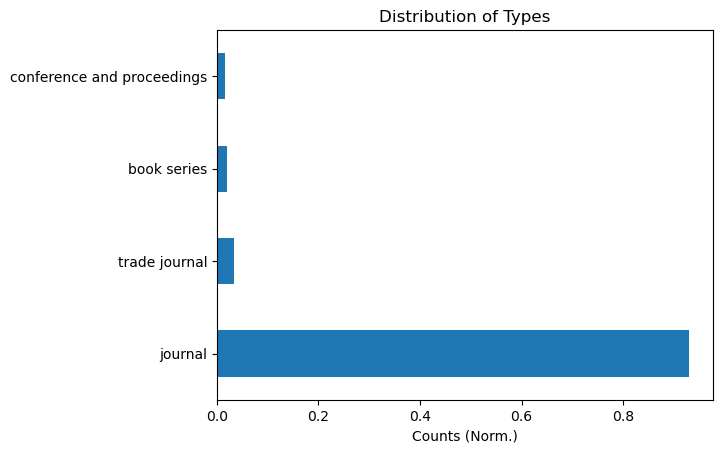

In [142]:
jour_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Types')

It looks like the types match up similarly with the publication types chosen for the `papers_df`. However, we have an additional category, `trade journal`, that may include some publications in the `papers_df`. Therefore, let's isolate the entries in `jour_df` to only inlcude the publications from `journal` and `trade journal`.

In [143]:
jour_df = jour_df[(jour_df['Type'] == 'journal') | (jour_df['Type'] == 'trade journal')]

Let's assess the remaining null values.

In [144]:
jour_df.isna().sum()

Title       0
Type        0
SJR        78
H index     0
Country     0
Region      0
dtype: int64

Isolating the entries to only include publications from `journal` and `trade journal` sucessfully reduced the number of null values of `SJR` by 12.

To conclude, we reduce the occurrence of null values and identify and remove duplicate entries in `jour_df` by identifying formatting errors and inconsistencies in the entries and features.

---

## 1.5 Reformatting the Publication Source Titles in `jour_df` and `papers_df` 

Our end goal is to join the values in `jour_df` onto `papers_df` using the names of the publications. For the joining to work, the names of the publications must have the same format. Therefore, we must apply a standard strip format for all the values in both the `Title` column of `jour_df` and the `Source` column of `papers_df`. The format will follow the following criteria:

1. Encode the title in ASCII
2. No leading articles (Remove The, A/An at the beginning of the Titles)
3. Replace the character `&` with `and`
4. Remove remaining special characters
5. Remove double spacing
6. Remove any qualifiers such as `(discontinued)`
7. All characters are lower case

The goal of **Section 1.5** is to use the function `edit_title` to apply these formatting edits using regex

In [145]:
import re

def edit_title(row):
    '''
    
    This function takes publication source and uses regex to edit the format of that value.
    
    Parameters:
    ---------
    row: The title of the publication source.
    
    Return:
    ------
    ret: The reformatted title of the publication source.
    '''
    title = row
    
    assert isinstance(title, str), 'Input parameter must be a string'
    
    # Encode the titles in ASCII 
    title = title.encode('ascii', 'ignore').decode('ascii')
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of '(discontinued)'
    title = re.sub(r'\(discontinued\)', '', title)
    
    # Insert spaces in '&word' case
    title = re.sub(r'\&\+?', 'and ', title)
    
    # Get rid of special characters 
    title = re.sub(r'[!@#$%\^\*\(\)-:\.=,\+\_]', '', title)
    
    # Get rid of double spacing
    title = re.sub(r'  ', ' ', title)
    
    return title.strip().lower()

### 1.5.1 Reformatting Values in `jour_df`
We'll assign the data frame with the reformatted values for `Title` under the variable `test_df`.

In [146]:
test_df = jour_df.assign(Title = jour_df['Title'].apply(edit_title))

In [147]:
test_df.head(10)

,Title,Type,SJR,H index,Country,Region
6003,nature,journal,17.897,1276.0,United Kingdom,Western Europe
6004,science,journal,14.589,1229.0,United States,Northern America
6006,proceedings of the national academy of science...,journal,4.184,805.0,United States,Northern America
675,chemical reviews,journal,18.718,745.0,United States,Northern America
6140,physical review letters,journal,3.246,647.0,United States,Northern America
9,journal of the american chemical society,journal,5.728,644.0,United States,Northern America
11,angewandte chemie international edition,journal,5.126,579.0,United Kingdom,Western Europe
1786,advanced materials,journal,8.663,563.0,United States,Northern America
676,chemical society reviews,journal,14.529,552.0,United Kingdom,Western Europe
17,nano letters,journal,3.761,511.0,United States,Northern America


Let's check to make sure the number of unique values in `Title` are preserved.

In [148]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

There are 1 more unique values in jour_df than test_df


Since there are more unique values in `jour_df` than `test_df`, that means there are two entires containing unique metrics for what would be considered as the same publication. This poses an issue since we are using the `Title` column as the primary key for `jour_df`. To help remove this ambiguity, let's see what the duplicated title is.

In [149]:
test_df.groupby('Title').size()[test_df.groupby('Title').size() > 1]

Title
biotech    2
dtype: int64

In [150]:
print('Before the formatting')
display(jour_df.loc[[4900,258], :])

print('After the formatting')
display(test_df[test_df['Title'] == 'biotech'])

Before the formatting


,Title,Type,SJR,H index,Country,Region
4900,3 Biotech,journal,0.522,49.0,Switzerland,Western Europe
258,BioTech,journal,0.530,15.0,Switzerland,Western Europe


After the formatting


,Title,Type,SJR,H index,Country,Region
4900,biotech,journal,0.522,49.0,Switzerland,Western Europe
258,biotech,journal,0.530,15.0,Switzerland,Western Europe


It looks like there is two entries for `biotech`, one that originally was lead with a 3, and another that was not. Looking up `3 Biotech` on the [website](https://www.scimagojr.com/) didn't yield any results with that specific title, so likely an importing issue caused the format of the title to be `3 Biotech` and not `Biotech`. However, the two different values of `SJR` and `H index` suggest these entries are different publications. Despite this, we will apply our prior protocol so that entry with the larger value of `H index` will be kept since it has the highest chance of people the actual publication that would be cited.

In [151]:
test_df = test_df.drop(4900)
jour_df = jour_df.drop(4900)

Let's check again to make sure the number of unique values in `Title` are preserved.

In [152]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

True


The value counts match! Next, let's check for any blank values in `Title` since encoding the values in ASCII would leave an empty string if there were no English letters, numbers or specific special characters.

In [153]:
test_df['Title'][test_df['Title'] == ''].count()

0

There are no blank values in the `Title` column. Finally, let's check the null values in `test_df`.

In [154]:
test_df.isna().sum()

Title       0
Type        0
SJR        78
H index     0
Country     0
Region      0
dtype: int64

There are no additional null values introduced.

### 1.5.1 Reformatting Values in `papers_df`

In `papers_df`, the name of the publication is stored in the column `Source`. Let's pass the values in `Source` into the same formatting method `edit_title` applied on the `Title` column of `jour_df`. Similarly to the process we applied in part 2, we'll assign the data frame with the reformatted values for `Source` under the variable `test_df`.

In [155]:
test_df = papers_df.assign(Source = papers_df['Source'].apply(edit_title))

In [159]:
test_df['Source'].sample(10)

2532     advanced optical materials
4511                   nano letters
8130         tecnologa y desarrollo
1895             nouv j chim;france
10289                        carbon
20330           faraday discussions
6765                  small methods
4348                       acs nano
23031        chemistry of materials
23566        ceramics international
Name: Source, dtype: object

Let's check to make sure the number of unique values in `Source` are preserved.

In [160]:
result = test_df['Source'].value_counts().count() == papers_df['Source'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract( test_df['Source'].value_counts().count(), papers_df['Source'].value_counts().count()))
    if papers_df['Source'].value_counts().count() > test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in papers_df than test_df')
    elif papers_df['Source'].value_counts().count() < test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than papers_df')
else:
    print(result)

There are 818 more unique values in papers_df than test_df


We lost some unique values in `Source` between `papers_df` in `test_df`. However, unlike the `Title` column in `jour_df`, we don't need to worry about the loss of unique publication titles since `Source` won't be the primary key to join `papers_df` and `jour_df`, rather it is the foreign key for `papers_df`. If anything, the loss of 818 unique titles will hopefully ensure more entires in `papers_df` will be able to join to `jour_df` since their formatting is consistent.

Next, let's check if there are any blank values in the `Source` column of the `test_df`

In [161]:
test_df['Source'][test_df['Source'] == ''].count()

107

There are 107 entires with blank values in `papers_df`. These were expected since there were entires that used alphabets other than English, such as Russian, Mandarin, and Korean. Ideally, we could attempt to translate the names of these entries into English to see if there are matching entires in `jour_df`, but for the sake of time we will delete these entries since they only represent about 0.3% of the entires.

In [162]:
test_df = test_df.drop(test_df['Source'][test_df['Source'] == ''].index)

Let's double check to make sure all the blank entires were accounted for.

In [163]:
test_df['Source'][test_df['Source'] == ''].count()

0

All the blank entries were successfully removed. Now let's check for null values in `Source`

In [164]:
test_df['Source'].isna().sum()

0

There are no additional null values introduced. Let's replace `papers_df` with the data frame stored in `test_df` and save `papers_df` as a pickle.

To conclude, in this section we cleaned the columns `jour_df` to ensure each column was assigned to an appropriate data type, and to ensure the formatting of the publication titles for `paper_df` and `jour_df` were consistent so that they could act as keys to join the data frames.

---

## 1.6 Optimizing `papers_df` and `jour_df` for Memory Efficiency 

The goal of **Part 3** is to modify the entries and features of `papers_df` and `join_df` so that the data frame uses the least amount of memory possible. This is assist with loading and modifying the data frame in the future.

### 1.6.1 Optimizing `papers_df`

Let's start by look examining data types assigned to the columns in `papers_df`.

In [ ]:
papers_df.info()

Here, we see that `papers_df` currently takes up over 2.8 MB of memory and that each of the numeric data types are 64 bit. Let's see if we can change the data types of the numeric data so that `papers_df` uses less memory. We can do so by writing a script that finds the max value in the feature and assigning the lowest memory data type to that feature that can precisely store that value.

For example, assuming the maximum value of the entries in `Year` is 2023 (the current year), we can write a script that checks if 2023 is less than the maximum value of each integer type up to `int64` and assigns the smallest data type to `Year` that meets that condition. The maximum values of each data types are shown in the table below:

In [ ]:
import tabulate
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray([f'float{i}' for i in arr[:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

# Making a new arr for display purposes
display_arr = arr.copy()
display_arr[:,3] = np.asarray(['{:,}'.format(int((2**i)/2)) for i in arr[:,2]]) # formatting values of MaxiumValue
tabulate.tabulate(display_arr, tablefmt='html', headers=('IntegerType', 'FloatType', 'Bits', "MaximumValue"), stralign='center', numalign = 'center')

Here, since 2023 is less than 32,768 but larger than 128 `Year` would be assigned to a 16 bit type. More specifically, since years don't have any decimals, it would assigned to `int16`. To start, we'll begin by assigning integer data types to numeric columns that already assigned an integer data type, as well as columns that assigned to be floats but should actually be integers (example, `Year` and `profile_id`).

In [ ]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = papers_df.select_dtypes('number').drop(['CitesPerYear'],axis = 1).columns

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,0]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,0])
            break

In [ ]:
papers_df.info()

Here we see that applying this method lowered the memory usage for `papers_df` by 1 MB. Let's repeat the same process but for the float type column `CitesPerYear`.

In [ ]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = ['CitesPerYear']

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,1]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,1])
            break

In [ ]:
papers_df.info()

The memory usage for `papers_df` was reduced by 0.1 MB. Now, let's assess the object type columns. For training and testing a model, we want columns represented numerically, so unless an object column serves another purpose, it should either be excluded from the data set or be represented numerically. We want to keep `Authors` and `Source` as object data types since we plan to engineer those values to serve as foreign and primary keys. Additionally, `Title` should be kept as a unique identifier between citation entries. In contrast, the columns `CitesURL` and `CitationURL` can be removed since they don't contain any information about the citations we can use to determine their prestige ranking. Additionally, `QueryDate` can be removed since we queried all the entries on the same day. Therefore, let's remove the columns with object data type besides `Authors`,`Source` and `Title`.

In [ ]:
papers_df = papers_df.drop(['CitesURL', 'CitationURL', 'QueryDate'], axis = 1)

In [ ]:
papers_df.info()

Reducing the number of object columns reduced the memory usage of `paper_df` by 0.6 MB! 

### 1.6.2 Optimizing `jour_df`

Let's start by look examining data types assigned to the columns in `jour_df`.

In [165]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6276 entries, 6003 to 6257
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6276 non-null   object 
 1   Type     6276 non-null   object 
 2   SJR      6198 non-null   float64
 3   H index  6276 non-null   float16
 4   Country  6276 non-null   object 
 5   Region   6276 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 306.4+ KB




To conclude, we modified the data types of the numeric entries and reduced the number of object columns in `papers_df`to reduced its memory usage by 1.7 MB (39%).

---

# Section 2: Addressing Authorship Ambiguity via Feature Engineering 

In [ ]:
papers_df['Authors'] = papers_df['Authors'].str.strip()
papers_df['Authors'] = papers_df['Authors'].str.rsplit(',')

In [ ]:
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df['Authors'].values])
display(auth_df)

In [ ]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

In [ ]:
display(auth_df)

Let's append this data frame to `papers_df` and drop the `Authors` column.

In [ ]:
papers_df = pd.concat([auth_df, papers_df.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df` let's save it as a pickle.`

In [ ]:
papers_df.sample(5)

In [ ]:
papers_df.to_pickle('2023-03-24_NB1_papers_df_part4.pkl')

In [ ]:
import re

def edit_names(name):
    
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[^a-zA-Z\s]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    return [edit_names(i) for i in row]

def edit_profile_names(row):
    split_col = [i.strip() for i in row['profile'].rsplit(' - ')]
    name = split_col[0]
    ret_val = edit_names(name)
    return ret_val

In [ ]:
profile_df = profile_df.assign(profile_author = profile_df.apply(edit_profile_names, axis = 1))

In [ ]:
profile_df.sample(3)

In [ ]:
result = profile_df['profile_author'].value_counts().sum() == profile_df['profile'].value_counts().sum()
print('Are the number of unqiue Queries maintained?\t', result)

In [ ]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']] = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

In [ ]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(3)

In [ ]:
idx = papers_df[papers_df['third_auth'].isna()].index
papers_df = papers_df.drop(idx)

In [ ]:
uni_auth = np.unique(np.concatenate(np.asarray(papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']])))

In [ ]:
pd.Series(uni_auth).value_counts().sort_values()

In [ ]:
papers_df.isna().sum()

In [ ]:
papers_df.isna().sum()

First, let's remove all redundent publications.

In [ ]:
papers_df['Title'].value_counts().count()

In [ ]:
papers_df['Title'] = papers_df['Title'].str.lower()

In [ ]:
for i in papers_df.index:
    title = papers_df.loc[i, 'Title']
    if np.char.find(title, 'supporting information') != -1 \
        or np.char.find(title, 'reply to the comment') != -1 \
        or np.char.find(title, '{sub') != -1\
        or np.char.find(title, 'correction') != -1\
        or np.char.find(title, 'erratum') != -1:
        papers_df = papers_df.drop(i)

In [ ]:
papers_df.shape

In [ ]:
papers_df['Title'].value_counts().count()

In [ ]:
papers_df['Title'] = papers_df['Title'].str.replace(r'[^a-zA-Z\s]', '', regex = True)

In [ ]:
papers_df['Title'].value_counts().count()

In [ ]:
papers_df.shape

Make a `join_df`

In [ ]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [ ]:
join_df.head()

In [ ]:
result = papers_df.shape[0] == join_df.shape[0]
print('Are the number of rows maintained?\t', result)

In [ ]:
from difflib import SequenceMatcher

def custom_tokenizer(text):
    tokens = text.split()
    tokens = tokens[-1][-2:].lower()
    return tokens

def all_same(itemlist):
    '''
    Dermines if all the elements in a list are the same.
    
    '''
    return all(x == itemlist[0] for x in itemlist)

def get_unique_auth(df):
    
    author_list = np.concatenate(df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
    auth_ser = pd.Series(author_list)
    
    og_names = auth_ser.unique().shape[0]
    print(f"There are {og_names} unique author names")
    return og_names

def get_token_tag(text):
    
    pass_letters =  ['x', 'y', 'z']
    pass_lastname = ['ee', 'ng', 'im', 'iu', 'an', 'on', 'ao', 'wu', 'hu']
    
    if isinstance(text, str):
        
        token = custom_tokenizer(text)
        if token not in pass_lastname and\
            text[0] not in pass_letters:
            return True
        else:
            return False
    
    elif isinstance(text, list):
        
        a, b = text

        token_a = custom_tokenizer(a)
        token_b = custom_tokenizer(b)
        
        if a != b and a[0] == b[0] and\
            a[0] not in pass_letters and\
            b[0] not in pass_letters and\
            token_a not in pass_lastname and\
            token_b not in pass_lastname:
            
            return True

        else:
            return False
        
def pull_name3(row, v, col = None, token_state = 'on', input_ratio = 0.90):
    
    '''
    For each title in the data set, check if there is more than one citation. If there is, check
    if the first authors names are formatted in the same way. If not, print the variation of the 
    name that is the longest.
    '''
    if v == 'v1':
        og_vals = row
    elif v == 'v2':
        og_vals = row[col].values
    
    #print(og_vals)
    new_vals = np.unique([i for i in og_vals if isinstance(i, str)])
    
    last_names = [i.rsplit(' ')[-1] for i in new_vals] # make a list of the last names
    first_initial = [i.rsplit(' ')[0][0] for i in new_vals] # make a list of the first initial
    
    if len(new_vals) > 1:
        
        replace_dic = {}
        
        if all_same(new_vals) == False:
            
            for i in range(0, len(new_vals)):
                    
                for j in range(i+1, len(new_vals)):
                        
                    a = new_vals[i]
                    b = new_vals[j]
                    
                    first_a, last_a = first_initial[i], last_names[i]
                    first_b, last_b = first_initial[j], last_names[j]
                            
                    ## These are letters that many asian names that would be considered > 80% similar by the seqeunce matcher would start with, but the names are meant to be different
                    
                    if token_state == 'on':
                        token_tag = get_token_tag([a,b])
                        ratio_tag = True
                    elif token_state == 'off':
                        token_tag = True
                        ratio_tag = False
                        
                    if token_tag == True:
                        
                        # If both names share the same last name and first inital
                        if last_a == last_b and first_a == first_b:
                            
                            name = [a,b]
                            name.sort(reverse = False, key = len)
                            replace_dic.update({name[0] : name[1]})
                    
                        else:
                            
                            if ratio_tag == True:
                            
                                r = SequenceMatcher(None, a, b).ratio()

                                if r > input_ratio: # if the names are at least 85% similar

                                    name = [a,b]
                                    name.sort(reverse = False, key = len)
                                    replace_dic.update({name[0] : name[1]})
                    else:
                        pass
                        
        if len(replace_dic) != 0: #if replace_dic is not empty
            return replace_dic
        else:
            return False
    else:
        return False

In [ ]:
### NEED TO ENSURE THAT THE profile COLUMN DOES NOT CHANGE ###

def row_wise(df):
    
    print('-- Comparing Names Row Wise --')
    
    ## 1. Initiate the Replacement Dictionary 
    replace_dic = {}

    # Loop over each author column
    name_arr = np.asarray(df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']])

    for i in tqdm(range(name_arr.shape[0])):
        return_vals = pull_name3(name_arr[i, :], v = 'v1', token_state = 'on', input_ratio = 0.80)
        if return_vals:
            replace_dic.update(return_vals)
    
    return replace_dic, 'Row Wise', '#0072b2'

def groupby_profileAuthor(df):
    
    print('-- Comparing the names by profile_author --')
    
    # 1. Initiate the Replacement Dictionary 
    replace_dic = {}
    
    for i in tqdm(['first_auth', 'second_auth', 'third_auth']):
        return_vals = df.groupby('profile_author').apply(pull_name3, v = 'v2', col = i, input_ratio = 0.87).values
        for k in return_vals[return_vals != False]:
            replace_dic.update(k) 
            
    return replace_dic, 'profile Wise', '#d55e00'

In [ ]:
new_join_df = join_df.copy()
j = 0

auth_cols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']
auth_subcols = ['first_auth', 'second_auth', 'third_auth']

plt_dic = {'num_auth': [], 'labels': [], 'colors': [], 'iteration': [], 'change_first':[], 'change_second': [], 'change_third': [], 'change_profile': []}

num = get_unique_auth(join_df);
plt_dic['num_auth'].append(num)
plt_dic['labels'].append('Start')
plt_dic['colors'].append('#009e73')
plt_dic['iteration'].append(j)

for key in list(plt_dic.keys())[4:]:
    plt_dic[key].append(0)
    
while j < 5:
    
    print('\n')
    print(f'--- Performing Cycle {j+1} ---')
    print('\n')
    
    for func in [row_wise, groupby_profileAuthor]:
        
        replace_dic, label, color = func(join_df)
        
        compare_join_df = join_df.copy()
        
        join_df.loc[:, auth_subcols] = join_df.replace(replace_dic).loc[:, auth_subcols]
        num = get_unique_auth(join_df);
        plt_dic['num_auth'].append(num)
        plt_dic['labels'].append(label)
        plt_dic['colors'].append(color)
        plt_dic['iteration'].append(j)
        
        
        # Calculting the change in author names by column
        check_df = compare_join_df.loc[:, auth_cols] == join_df.loc[:, auth_cols]
        changed_ser = check_df.count() - check_df.sum()
        ch_first, ch_second, ch_third, ch_profile = changed_ser
        plt_dic['change_first'].append(ch_first)
        plt_dic['change_second'].append(ch_second)
        plt_dic['change_third'].append(ch_third)
        plt_dic['change_profile'].append(ch_profile)
        
        print('\n')
    
    j = j + 1

In [ ]:
num_auth = np.asarray(plt_dic['num_auth'])
shift_arr = np.subtract(num_auth[:len(num_auth)-1], num_auth[1:]) # shifted the array to perform subtraction 
diff_arr = np.append(0, shift_arr)
plt_dic['repl_auth'] = diff_arr # the number of replaced author names for reach step

`repl_auth` = $\frac{\Delta \text{Number of Authors}}{\text{Iteration}}$

In [ ]:
group_auth_df = pd.DataFrame(plt_dic)
group_auth_df

In [ ]:
gp1 = group_auth_df[group_auth_df['labels'] != 'Start']
gp2 = gp1.groupby(['labels']).sum()[['change_first', 'change_second', 'change_third', 'change_profile']]
ch_sum = np.sum(gp2.values, axis = 1)

per_df = pd.DataFrame(np.divide(gp2.values, ch_sum.reshape(-1, 1)), index = gp2.index, columns = gp2.columns)
per_df.plot.barh(stacked=True)

In [ ]:
list(plt_dic.keys())[4:]

In [ ]:
for key in list(plt_dic.keys())[4:8]:
    plt.plot(plt_dic[key][1:], marker = 'o', label = key, ls = 'dashed')
plt.legend()

In [ ]:
group_auth_df = group_auth_df[group_auth_df['labels'] != 'Start']

fig, axes = plt.subplots(2, 2)

ax = axes[0,0]
colors = group_auth_df.groupby('labels')['colors'].apply(list).str[0].values.tolist()
bar_plot = group_auth_df.groupby('labels')['repl_auth'].sum().plot(kind = 'barh', color = colors, ax = ax)

bar_plot.set_title('Number of Author Names Replaced per Function Applied')
bar_plot.set_xlabel('Number of Author Names Replaced')
bar_plot.set_ylabel('Function Applied')


ax = axes[0,1]
colors = plt_dic['colors']
num_authors = plt_dic['num_auth']
labels = plt_dic['labels']

# The average number of unique authors per citation
uni_auth_per_cit = np.divide(num_authors, join_df.shape[0])

for i in range(len(num_authors)):
    ax.scatter(i, uni_auth_per_cit[i], label = labels[i], color = colors[i], marker = 'o', s = 50)

ax.plot(uni_auth_per_cit, color = 'black', ls = 'dashed', zorder = 0, alpha = 0.6)
ax.set_xlabel('Interation')

container, label = ax.get_legend_handles_labels()
ax.legend(container[:3], label[:3], title = 'Funciton Applied', )

##############

ax = axes[1,0]
group_int_lab = group_auth_df.groupby(['iteration', 'labels']).sum().unstack()['repl_auth']
stacked_plot = group_int_lab.plot.bar(stacked=True,ax = ax)

x_ticks = np.unique(plt_dic['iteration'])
x_tick_labels = np.unique(plt_dic['iteration']) + 1
stacked_plot.set_xticks(x_ticks, x_tick_labels, rotation = 0);
stacked_plot.set_xlabel('Number of Iterations')
stacked_plot.set_ylabel('Number of Author Names Replaced')
stacked_plot.legend(title = 'Funciton Applied')


fig.tight_layout()

In [ ]:
pd.DataFrame(plt_dic).to_pickle('2023-03-27_NB1_plt_df_part4.pkl')

Dropping rows with duplicated title names

In [ ]:
join_df = join_df.drop_duplicates('Title')
get_unique_auth(join_df);

In [ ]:
papers_df = join_df.reset_index(drop = True)

In [ ]:
papers_df = papers_df.drop('id', axis = 1)

In [ ]:
papers_df.info()

In [ ]:
papers_df.to_pickle('2023-03-27_NB1_papers_df_part4.pkl')

---